# Creating Spectrograms for Each ROI and Each Condition

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
#-----imports-----#
import numpy as np
from matplotlib import pyplot as plt

from mne import Epochs, create_info
from mne.io import RawArray
from mne.time_frequency import AverageTFRArray, EpochsTFRArray, tfr_array_morlet

import os
import matplotlib.pyplot as plt

In [3]:
import sys 
from pathlib import Path

# get project root 
project_root = Path("/Users/Tysia/Desktop/movidoc/tictrack_eeg_analysis")
sys.path.append(str(project_root))



### Load previous functions 

First pre-process data, then align tics from Excel and EEG data, then exctract pre tic epochs, based on that data make for each phase time-frequency analysis 

In [4]:
from _02_Movidoc_tictrack_prepro_TTL_extraction_patients import (
    load_data,
    extract_stimuli,
    preprocess_data, 
    apply_rest_reference,
    recalibrate_from_first_event,
    collect_ttl_with_phases
)

In [5]:
from _03_Movidoc_tictrack_tic_extraction_patients import extract_tics_from_excel

In [43]:
from _04_Movidoc_full_pipeline_analysis_patients import (
    assign_phase_to_tics,
    extract_eeg_phase_times_from_ttl,
    realign_excel_to_eeg,
    build_merged_ttl_tics,
    run_full_pipeline_for_patient,
    shift_urges_times,
    extract_random_epochs_in_phase,
    analyse_merged_ttl_tics,
    extract_pre_tic_epochs,
)

## Load the data 

For now one participant

In [314]:
# Base directory for this project
base_dir = "/Users/Tysia/Desktop/movidoc/tictrack_eeg_analysis"
patient_files_dir = os.path.join(base_dir, "PATIENT FILES")
eeg_dir = os.path.join(patient_files_dir, "EEG PATIENT FILES")
excel_dir = os.path.join(patient_files_dir, "EXCEL PATIENT FILES")



In [315]:
# Define patient configurations
patients = [
    {
        "montage": "standard_1020", # montage with 32 electrodes (from DS26 to BC29 : always 32 electrodes)
        "vhdr": os.path.join(eeg_dir, "MOVIDOCTicTrack000010.vhdr"),
        "excel": os.path.join(excel_dir, "DS26_annotations_binary-table_cutted.xlsx"),
        "fps": 30,
        "min_absence_frames": 30,
        "excel_phase_times": [13.728, 50.028, 190.080, 349.272, 980.727, 1277.991]
    },
    {
        "montage": "standard_1020", # montage with 32 electrodes (from DS26 to BC29 : always 32 electrodes)
        "vhdr": os.path.join(eeg_dir, "MOVIDOCTicTrack_BB28-bis.vhdr"), #BB28
        "excel": os.path.join(excel_dir, "BB28_annotations_binary-table_cutted.xlsx"),
        "fps": 25,
        "min_absence_frames": 25,
        "excel_phase_times": [9.840, 27.320, 156.880, 302.600, 929.960, 991.760]
    },
    {
        "montage": "standard_1020", # montage with 32 electrodes (from DS26 to BC29 : always 32 electrodes)
        "vhdr": os.path.join(eeg_dir, "MOVIDOCTicTrack000013.vhdr"), # BC29
        "excel": os.path.join(excel_dir, "BC29_annotations_binary-table_cutted_xlsx_Lizbeth.xlsx"),
        "fps": 30,
        "min_absence_frames": 30,
        "excel_phase_times": [17.391, 65.670, 201.597, 358.215, 1088.670, 1204.038]
    },
    {
        "montage": "standard_1005", # montage with 64 electrodes (from MM30 : always 64 electrodes)
        "vhdr": os.path.join(eeg_dir, "MOVIDOCTicTrack000030.vhdr"), # MM30
        "excel": os.path.join(excel_dir, "MM30_annotations_binary-table_cutted.xlsx"),
        "fps": 30,
        "min_absence_frames": 30,
        "excel_phase_times": [6.633, 68.277, 196.581, 323.994, 931.194, 995.049]
    },
    {
        "montage": "standard_1005", # montage with 64 electrodes (from MM30 : always 64 electrodes)
        "vhdr": os.path.join(eeg_dir, "MOVIDOCTicTrack000031.vhdr"), # SC31
        "excel": os.path.join(excel_dir, "SC31_annotations_binary-table_cutted.xlsx"),
        "fps": 30,
        "min_absence_frames": 30,
        "excel_phase_times": [12.243, 62.040, 191.664, 345.972, 970.200, 1074.546]
    }
]

## Run full pipeline and extract pre-tic epochs 

In [339]:
def full_pipeline_extract_pre_tic_epochs(patient, phase,nb_random_epochs):
    # Run the full pipeline for the patient
    results = run_full_pipeline_for_patient(
        vhdr_path = patient["vhdr"],
        excel_path = patient["excel"],
        fps = patient["fps"],
        min_absence_frames = patient["min_absence_frames"],
        montage_name = patient["montage"],
        excel_phase_times = patient["excel_phase_times"],
        )
        
    phase_map = {
        "spontaneous_phase": ("start_spont", "end_spont"),
        "imitated_phase": ("start_imit", "end_imit"),
        "suppressed_phase": ("start_ret", "end_ret"),
        }
    filter_dict = {
        'D': 21, 
        'F': 22,
        'S': 23,
        'T': 24,
        'right': 25,
        'start_spont': 9,
        'end_spont': 10,
        'start_imit': 11,
        'end_imit': 12,
        'start_ret': 13,
        'end_ret': 14
        }
    phase_start_key, phase_end_key = phase_map[phase]

    #set the phase boundary 
    start_ttl_number = filter_dict[phase_start_key]
    end_ttl_number   = filter_dict[phase_end_key]

  
    ttl_info = results["ttl"]  

    start_time = next(ttl["time"] for ttl in ttl_info if int(ttl["ttl_name"].split()[-1]) == start_ttl_number)
    end_time   = next(ttl["time"] for ttl in ttl_info if int(ttl["ttl_name"].split()[-1]) == end_ttl_number)


    # Urges list 
    urges_list = {}
    analysis_list_patient = analyse_merged_ttl_tics(
        merged_ttl_tics=results["merged_ttl_tics"],
        phase_start_key = phase_start_key, 
        phase_end_key = phase_end_key,
        )
    urges_list[f"list_urges_{results['subject']}"] = analysis_list_patient

    # Shift urges to EEG time
    urges_list = urges_list[f"list_urges_{results['subject']}"]
    stim2_time = results["stim2_time_original"]

    urges_times_EEG_patient = shift_urges_times(
        urges_list=urges_list,
        stim2_time=stim2_time,
        )

    # Extract pre-tic epochs
    pre_tic_epochs = extract_pre_tic_epochs(
        raw_cropped =results["raw_cropped"],
        urge_times =urges_times_EEG_patient,
        pre_seconds=2.0, post_seconds=0.5
        )

    # Extract random epochs in the same phase
    random_epochs = extract_random_epochs_in_phase(
        raw_cropped=results["raw_cropped"],
        start_time=start_time,
        end_time=end_time,
        n_epochs=nb_random_epochs,
        epoch_duration=2.5,
        event_id=999,
        seed=42
        )
    
    return pre_tic_epochs, random_epochs


===== START Patient /Users/Tysia/Desktop/movidoc/tictrack_eeg_analysis/PATIENT FILES/EEG PATIENT FILES/MOVIDOCTicTrack000030.vhdr =====

--- Traitement du fichier : 000030 ---

Extracting parameters from /Users/Tysia/Desktop/movidoc/tictrack_eeg_analysis/PATIENT FILES/EEG PATIENT FILES/MOVIDOCTicTrack000030.vhdr...
Setting channel info structure...
Reading 0 ... 822569  =      0.000 ...  1645.138 secs...


/Users/Tysia/Desktop/movidoc/tictrack_eeg_analysis/_02_Movidoc_tictrack_prepro_TTL_extraction_patients.py:62: RuntimeWarning: Online software filter detected. Using software filter settings and ignoring hardware values
  raw = mne.io.read_raw_brainvision(FilePath, preload=True)


['Fp1', 'F3', 'F7', 'FT9', 'FC5', 'FC1', 'C3', 'T7', 'TP9', 'CP5', 'CP1', 'Pz', 'P3', 'P7', 'O1', 'Oz', 'O2', 'P4', 'P8', 'TP10', 'CP6', 'CP2', 'Cz', 'C4', 'T8', 'FT10', 'FC6', 'FC2', 'F4', 'F8', 'Fp2', 'AF7', 'AF3', 'AFz', 'F1', 'F5', 'FT7', 'FC3', 'FCz', 'C1', 'C5', 'TP7', 'CP3', 'P1', 'P5', 'PO7', 'PO3', 'POz', 'PO4', 'PO8', 'P6', 'P2', 'CPz', 'CP4', 'TP8', 'C6', 'C2', 'FC4', 'FT8', 'F6', 'F2', 'AF4', 'AF8']
None
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1651 samples (3.302 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.6s


Filtering raw data in 1 contiguous segment


[Parallel(n_jobs=1)]: Done  63 out of  63 | elapsed:    2.1s finished


Removed notch frequencies (Hz):
     50.00 : 20664 windows
Applying REST reference...
Fitted sphere radius:         95.6 mm
Origin head coordinates:      -0.8 14.6 43.9 mm
Origin device coordinates:    -0.8 14.6 43.9 mm

Equiv. model fitting -> RV = 0.00488894 %%
mu1 = 0.943718    lambda1 = 0.139947
mu2 = 0.662473    lambda2 = 0.696217
mu3 = 0.282206    lambda3 = -0.0257945
Set up EEG sphere model with scalp radius    95.6 mm

EEG channel type selected for re-referencing
Applying REST reference.
Applying a custom ('EEG',) reference.
    63 out of 63 channels remain after picking
Before crop: [ 0.    17.538 17.546 24.272 24.28 ]
Cropping EEG at stimulus 'Stimulus/S  2' = 17.546 s
DEBUG after set_annotations: [17.546 24.272 24.28  26.312 26.328]
Used Annotations descriptions: [np.str_('Stimulus/S  2'), np.str_('Stimulus/S  3'), np.str_('Stimulus/S  4'), np.str_('Stimulus/S  5'), np.str_('Stimulus/S  6'), np.str_('Stimulus/S  7'), np.str_('Stimulus/S  8'), np.str_('Stimulus/S  9'), np.str

/Users/Tysia/Desktop/movidoc/tictrack_eeg_analysis/_04_Movidoc_full_pipeline_analysis_patients.py:679: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  epochs = mne.Epochs(


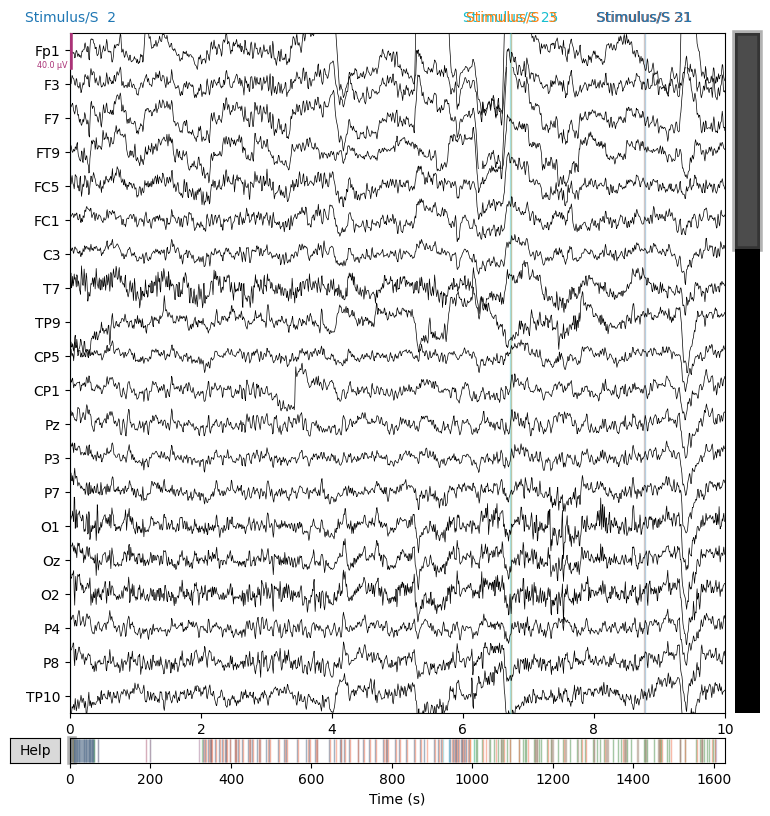

In [331]:
pre_tic_epochs_p1_spont, random_epochs_p1_spont = full_pipeline_extract_pre_tic_epochs(patients[3], phase="imitated_phase", nb_random_epochs=50)
print(random_epochs_p1_spont.events)


In [326]:
print(random_epochs_p1_spont.get_data())

[[[-5.01239991e-06 -5.89720448e-06 -7.27421665e-06 ...  1.65348151e-04
    1.60477999e-04  1.56222226e-04]
  [ 1.13224751e-06 -8.65204947e-07 -2.61409956e-06 ...  3.11608101e-05
    3.27850939e-05  3.31971913e-05]
  [ 5.05607738e-07 -1.08811408e-06 -3.18747536e-06 ...  4.76983607e-05
    4.73637338e-05  4.63446028e-05]
  ...
  [ 7.43320080e-06  7.11996667e-06  6.56226405e-06 ...  1.56162445e-05
    1.51157070e-05  1.41965463e-05]
  [ 2.03590738e-06  2.12092516e-06  1.54587946e-06 ...  6.21591165e-05
    5.98159204e-05  5.74216972e-05]
  [-9.41255420e-06 -6.46553403e-06 -4.21498123e-06 ...  7.94669750e-05
    7.54360637e-05  7.19232438e-05]]

 [[ 6.61511114e-06  5.96010620e-06  5.53926729e-06 ...  1.16564571e-04
    1.13394552e-04  1.10360715e-04]
  [-1.54784257e-06 -2.31388525e-07  1.11483527e-06 ... -1.42379695e-05
   -1.63174029e-05 -1.85628070e-05]
  [ 9.45363831e-07  2.96957046e-07 -2.41892386e-07 ... -1.96751049e-05
   -1.99687687e-05 -1.98591708e-05]
  ...
  [-3.28724819e-06 -1.0

In [319]:
print(len(pre_tic_epochs_p1_spont))
print(len(random_epochs_p1_spont))

8
50


## Time-frequency analysis 

In [68]:
import numpy as np
from matplotlib import pyplot as plt
import mne

from mne import Epochs, create_info
from mne.io import RawArray
from mne.time_frequency import AverageTFRArray, EpochsTFRArray, tfr_morlet

print(__doc__)

Automatically created module for IPython interactive environment


### Devide it to ROI to average it later 

In [300]:
def tfr_per_ROI(patient, pre_tic_epochs, epoch_type='pre_tic'):

    """
    epoch type : 'pre_tic' or 'random' (change in baseline values)
    """

    channels_to_use_32 = ["Cz", "C3", "C4", "Pz", "Fp1", "Fp2"]
    channels_to_use_64 = ["Cz", "FCz", "C3", "FC3", "CP3", "C4", "CP4", "FC4", "Pz", "CPz", "Fp1", "Fp2", "AF3", "AFz", "AF4"]

    roi_lists_32 = {
        "midline_premotor": ["Cz"],
        "left_sensorimotor": ["C3"],
        "right_sensorimotor": ["C4"],
        "midline_posterior": ["Pz"],
        "midline_prefrontal": ["Fp1", "Fp2"]
    }
    roi_lists_64 = {
        "midline_premotor": ["Cz", "FCz"],
        "left_sensorimotor": ["C3", "FC3", "CP3"],
        "right_sensorimotor": ["C4", "CP4", "FC4"],
        "midline_posterior": ["Pz", "CPz"],
        "midline_prefrontal": ["Fp1", "Fp2", "AF3", "AFz", "AF4"]
    }
    # Choice of the ROI depending on the patient's montaget
    if patient["montage"] == "standard_1020":
        channels_to_use = channels_to_use_32
        roi_lists = roi_lists_32
    elif patient["montage"] == "standard_1005":
        channels_to_use = channels_to_use_64
        roi_lists = roi_lists_64
    else:
        raise ValueError(f"Montage inconnu pour le patient {subject}: {patient['montage']}")

    epochs_roi = pre_tic_epochs.copy().pick(channels_to_use)


    # Time-Frequency Representation (TFR) computation using Morlet wavelets for each channel
    #Parameters
    freqs = np.arange(5.0, 50.0, 2.0)  # Frequencies from 5 to 50 Hz
    n_cycles = freqs / 2.0 # Number of cycles in Morlet wavelet


    power = epochs_roi.compute_tfr(
        method="morlet", 
        freqs=freqs,
        n_cycles=n_cycles, 
        return_itc=False, 
        average=True
    )
    #baseline correction (before averaging based on ROI)
    if epoch_type == 'pre_tic':
        baseline = ( -2, -0.5)
    else:
        baseline = (0, 2)

    power.apply_baseline(mode="logratio", baseline=baseline)

    #averaging power based on ROI
    print(power.ch_names)
    roi_tfr = {}
    for roi_name, roi_channels in roi_lists.items():
        picks = mne.pick_channels(power.ch_names, roi_channels)
        roi_power = power.data[picks].mean(axis=0)
        roi_tfr[roi_name] = roi_power


    return roi_tfr, power.freqs, power.times




In [332]:
tfr_results_p1_spont, freqs_p1_spont, times_p1_spont = tfr_per_ROI(patients[3], pre_tic_epochs_p1_spont, epoch_type='pre_tic')


Applying baseline correction (mode: logratio)
['Cz', 'FCz', 'C3', 'FC3', 'CP3', 'C4', 'CP4', 'FC4', 'Pz', 'CPz', 'Fp1', 'Fp2', 'AF3', 'AFz', 'AF4']
/Users/Tysia/Desktop/movidoc/tictrack_eeg_analysis/PATIENT FILES/EEG PATIENT FILES/MOVIDOCTicTrack000030.vhdr ⚠️ NO baseline samples time range: 0.0 2.5


[Parallel(n_jobs=1)]: Done  15 out of  15 | elapsed:    0.2s finished


In [333]:
tfr_results_p1_spont_random , freqs_p1_spont_random, times_p1_spont_random = tfr_per_ROI(patients[3], random_epochs_p1_spont, epoch_type='random')
print(tfr_results_p1_spont)

Applying baseline correction (mode: logratio)
['Cz', 'FCz', 'C3', 'FC3', 'CP3', 'C4', 'CP4', 'FC4', 'Pz', 'CPz', 'Fp1', 'Fp2', 'AF3', 'AFz', 'AF4']
/Users/Tysia/Desktop/movidoc/tictrack_eeg_analysis/PATIENT FILES/EEG PATIENT FILES/MOVIDOCTicTrack000030.vhdr ⚠️ NO baseline samples time range: 0.0 2.5
{'midline_premotor': array([[-0.44750849, -0.4487288 , -0.45077386, ..., -0.80729446,
        -0.80901443, -0.81125842],
       [-0.52929977, -0.53133391, -0.53409064, ..., -0.75522433,
        -0.75568531, -0.7567611 ],
       [-0.52761165, -0.5286624 , -0.5302999 , ..., -0.74646212,
        -0.745993  , -0.7461142 ],
       ...,
       [ 0.78933073,  0.78879064,  0.78769985, ...,  0.56281914,
         0.56395291,  0.56453357],
       [ 1.14492831,  1.14436039,  1.14324218, ...,  0.91903132,
         0.92012994,  0.92067853],
       [ 1.31032693,  1.30977543,  1.30867688, ...,  1.08469487,
         1.08576816,  1.08629421]]), 'left_sensorimotor': array([[-0.44775893, -0.44897716, -0.451020

[Parallel(n_jobs=1)]: Done  15 out of  15 | elapsed:    0.9s finished


In [246]:
def plot_trf_roi(tfr_results, freqs, times):

    vmin, vmax = -2, 2
    roi_names = list(tfr_results.keys())
    n_rois = len(roi_names)

    # Create a 2x3 grid
    fig, axs = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
    fig.suptitle("Pre-tic time–frequency representations (ROI-averaged)",fontsize=18,fontweight="bold")

    for i, roi_name in enumerate(roi_names):
        row, col = divmod(i, 3)  # row = i//3, col = i%3
        ax = axs[row, col]

        data = tfr_results[roi_name]

        im = ax.imshow(
            data,
            aspect="auto",
            origin="lower",
            extent=[times[0], times[-1], freqs[0], freqs[-1]],
            vmin=vmin,
            vmax=vmax,
            cmap="RdBu_r",
        )
        ax.set_title(f"{roi_name} – pre-tic TFR")
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Frequency (Hz)")
        ax.axvline(0, color="k", linestyle="--", linewidth=0.6)


    # Remove the empty subplot if you have fewer than 6 ROIs
    if n_rois < 6:
        for j in range(n_rois, 6):
            fig.delaxes(axs.flatten()[j])

    # Add a single colorbar for all plots
    cbar = fig.colorbar(im, ax=axs, orientation="vertical", fraction=0.02, pad=0.04)
    cbar.set_label("Power (log ratio)")

    return fig


## Spontaneous tics phase -- Patient 1


===== START Patient /Users/Tysia/Desktop/movidoc/tictrack_eeg_analysis/PATIENT FILES/EEG PATIENT FILES/MOVIDOCTicTrack_BB28-bis.vhdr =====

--- Traitement du fichier : _BB28-bis ---

Extracting parameters from /Users/Tysia/Desktop/movidoc/tictrack_eeg_analysis/PATIENT FILES/EEG PATIENT FILES/MOVIDOCTicTrack_BB28-bis.vhdr...
Setting channel info structure...
Reading 0 ... 841719  =      0.000 ...  1683.438 secs...


/Users/Tysia/Desktop/movidoc/tictrack_eeg_analysis/_02_Movidoc_tictrack_prepro_TTL_extraction_patients.py:62: RuntimeWarning: Online software filter detected. Using software filter settings and ignoring hardware values
  raw = mne.io.read_raw_brainvision(FilePath, preload=True)


['Fp1', 'F3', 'F7', 'FT9', 'FC5', 'FC1', 'C3', 'T7', 'TP9', 'CP5', 'CP1', 'Pz', 'P3', 'P7', 'O1', 'Oz', 'O2', 'P4', 'P8', 'TP10', 'CP6', 'CP2', 'Cz', 'C4', 'T8', 'FT10', 'FC6', 'FC2', 'F4', 'F8', 'Fp2']
None
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1651 samples (3.302 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


Filtering raw data in 1 contiguous segment


...

Removed notch frequencies (Hz):
     50.00 : 10385 windows
Applying REST reference...
Fitted sphere radius:         96.0 mm
Origin head coordinates:      -0.9 13.5 42.7 mm
Origin device coordinates:    -0.9 13.5 42.7 mm

Equiv. model fitting -> RV = 0.00406411 %%
mu1 = 0.943578    lambda1 = 0.140053
mu2 = 0.664225    lambda2 = 0.686726
mu3 = 0.0340156    lambda3 = -0.01641
Set up EEG sphere model with scalp radius    96.0 mm

EEG channel type selected for re-referencing
Applying REST reference.
Applying a custom ('EEG',) reference.
    31 out of 31 channels remain after picking
Before crop: [ 0.     4.482  4.492 19.53  19.538]
Cropping EEG at stimulus 'Stimulus/S  2' = 19.538 s
DEBUG after set_annotations: [19.538 29.424 29.432 31.616 31.632]
Used Annotations descriptions: [np.str_('Stimulus/S  2'), np.str_('Stimulus/S  3'), np.str_('Stimulus/S  4'), np.str_('Stimulus/S  5'), np.str_('Stimulus/S  6'), np.str_('Stimulus/S  7'), np.str_('Stimulus/S  8'), np.str_('Stimulus/S  9'), np.str_

/Users/Tysia/Desktop/movidoc/tictrack_eeg_analysis/_04_Movidoc_full_pipeline_analysis_patients.py:679: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  epochs = mne.Epochs(
[Parallel(n_jobs=1)]: Done   6 out of   6 | elapsed:    0.1s finished


Applying baseline correction (mode: logratio)


[Parallel(n_jobs=1)]: Done   6 out of   6 | elapsed:    0.4s finished


['Cz', 'C3', 'C4', 'Pz', 'Fp1', 'Fp2']
/Users/Tysia/Desktop/movidoc/tictrack_eeg_analysis/PATIENT FILES/EEG PATIENT FILES/MOVIDOCTicTrack_BB28-bis.vhdr ⚠️ NO baseline samples time range: 0.0 2.5
{'midline_premotor': array([[-0.05302615, -0.0496369 , -0.04686617, ...,  0.23024392,
         0.22946187,  0.22812533],
       [ 0.00566599,  0.00967355,  0.01316539, ...,  0.37854296,
         0.378742  ,  0.37832369],
       [-0.16525504, -0.16421448, -0.16364705, ...,  0.4296132 ,
         0.42927034,  0.42835687],
       ...,
       [-0.08513045, -0.0827806 , -0.08062477, ...,  0.40060696,
         0.40517523,  0.40908017],
       [ 0.50614182,  0.51202189,  0.51756084, ...,  0.80224395,
         0.80408545,  0.80543941],
       [ 1.11756319,  1.11904676,  1.11998867, ...,  1.53613835,
         1.53654858,  1.53645428]]), 'left_sensorimotor': array([[0.20243013, 0.20559929, 0.20816861, ..., 0.43993608, 0.43970668,
        0.43885964],
       [0.29811334, 0.3008668 , 0.30308073, ..., 0.5755

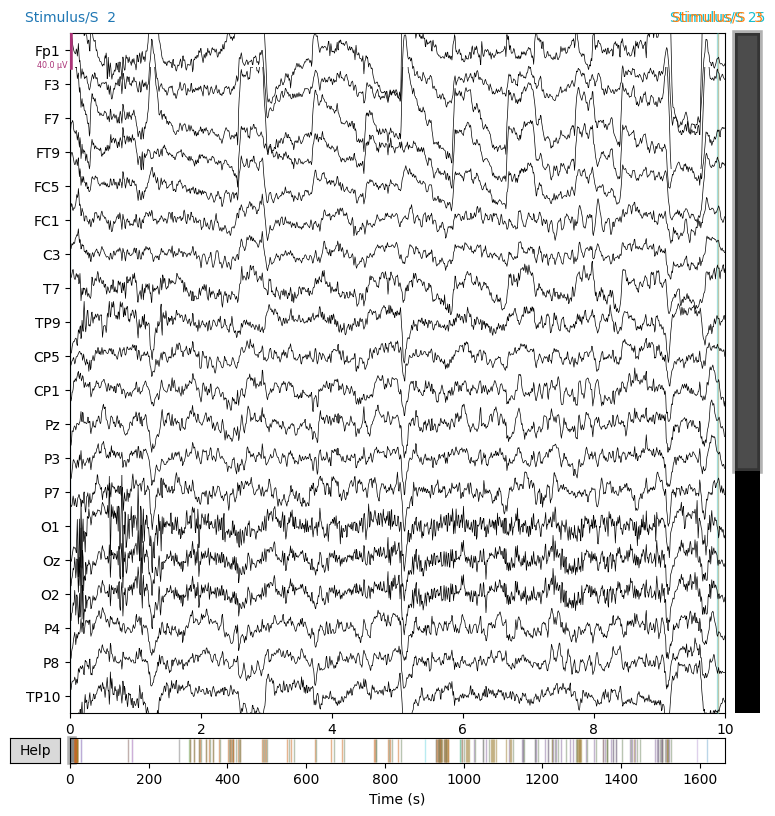

In [346]:
pre_tic_epochs_p1_spont, random_epochs_p1_spont = full_pipeline_extract_pre_tic_epochs(patients[1], phase="imitated_phase", nb_random_epochs=50)

tfr_results_p1_spont, freqs_p1_spont, times_p1_spont = tfr_per_ROI(patients[1], pre_tic_epochs_p1_spont)
tfr_results_p1_spont_random , freqs_p1_spont_random, times_p1_spont_random = tfr_per_ROI(patients[1], random_epochs_p1_spont, epoch_type='random')
print(tfr_results_p1_spont)


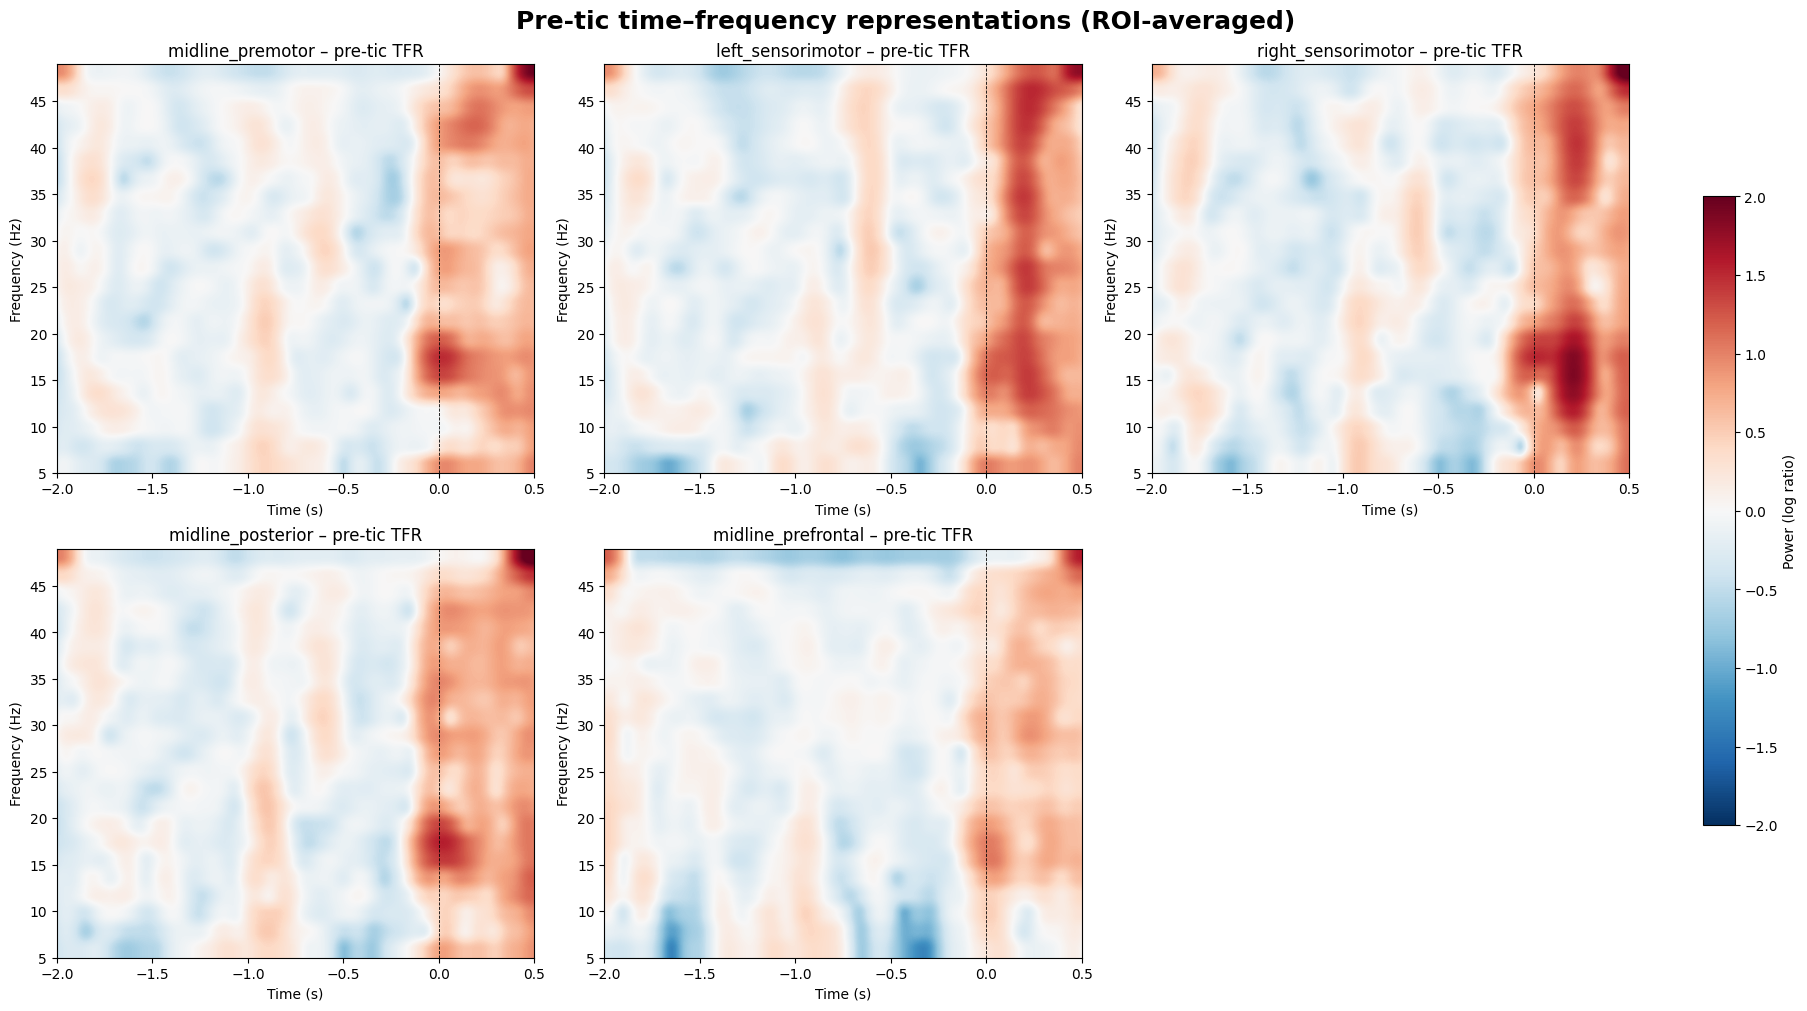

In [344]:

fig = plot_trf_roi(tfr_results_p1_spont, freqs_p1_spont, times_p1_spont)
plt.show()


## Spontaneous phase no-tic -- Patient 1

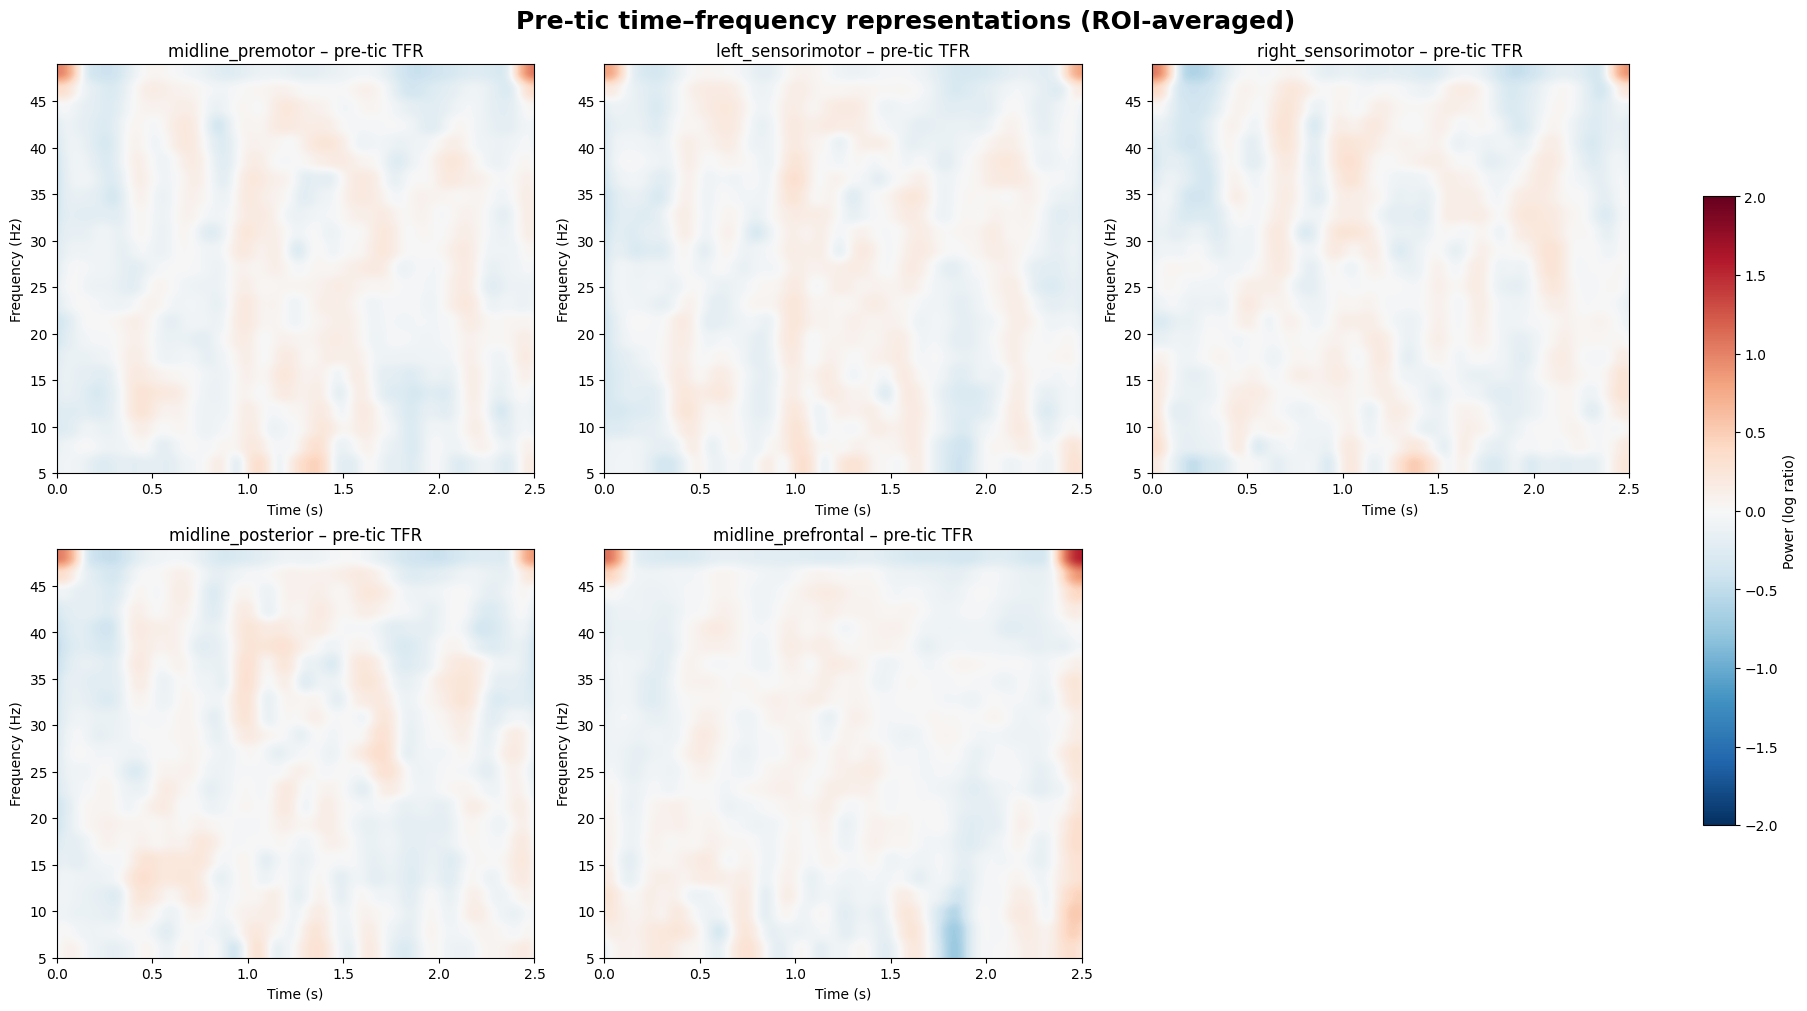

In [345]:
fig = plot_trf_roi(tfr_results_p1_spont_random, freqs_p1_spont_random, times_p1_spont_random)
plt.show()

### Loop over patients and phases 

In [249]:
import os
import re

def get_patient_id(patient):
    fname = os.path.basename(patient["vhdr"])
    match = re.search(r"\d+", fname)
    return match.group(0) if match else "unknown"



===== START Patient /Users/Tysia/Desktop/movidoc/tictrack_eeg_analysis/PATIENT FILES/EEG PATIENT FILES/MOVIDOCTicTrack000010.vhdr =====

--- Traitement du fichier : 000010 ---

Extracting parameters from /Users/Tysia/Desktop/movidoc/tictrack_eeg_analysis/PATIENT FILES/EEG PATIENT FILES/MOVIDOCTicTrack000010.vhdr...
Setting channel info structure...
Reading 0 ... 837089  =      0.000 ...  1674.178 secs...


/Users/Tysia/Desktop/movidoc/tictrack_eeg_analysis/_02_Movidoc_tictrack_prepro_TTL_extraction_patients.py:62: RuntimeWarning: Online software filter detected. Using software filter settings and ignoring hardware values
  raw = mne.io.read_raw_brainvision(FilePath, preload=True)


['Fp1', 'F3', 'F7', 'FT9', 'FC5', 'FC1', 'C3', 'T7', 'TP9', 'CP5', 'CP1', 'Pz', 'P3', 'P7', 'O1', 'Oz', 'O2', 'P4', 'P8', 'TP10', 'CP6', 'CP2', 'Cz', 'C4', 'T8', 'FT10', 'FC6', 'FC2', 'F4', 'F8', 'Fp2']
None
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1651 samples (3.302 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.6s


Filtering raw data in 1 contiguous segment


...

/Users/Tysia/Desktop/movidoc/tictrack_eeg_analysis/_04_Movidoc_full_pipeline_analysis_patients.py:679: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  epochs = mne.Epochs(


Applying baseline correction (mode: logratio)


[Parallel(n_jobs=1)]: Done  15 out of  15 | elapsed:    0.2s finished


Applying baseline correction (mode: logratio)


[Parallel(n_jobs=1)]: Done  15 out of  15 | elapsed:    1.0s finished


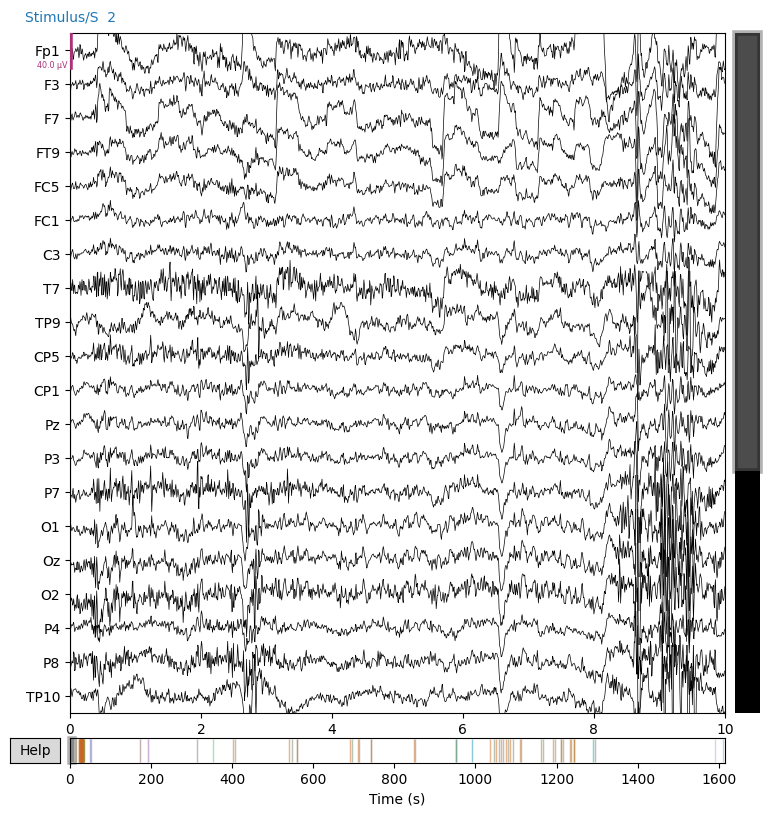

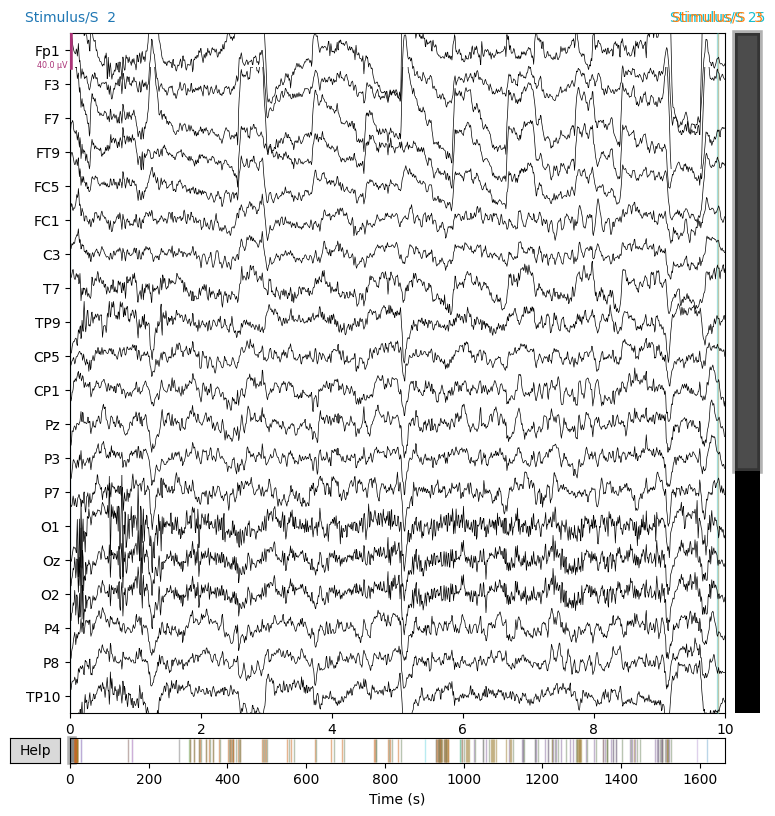

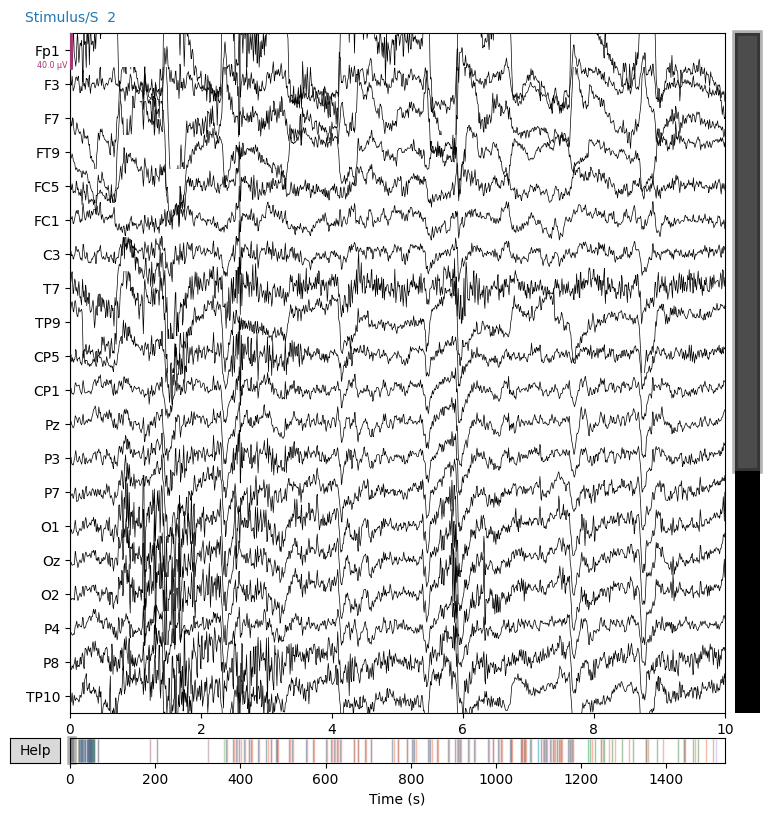

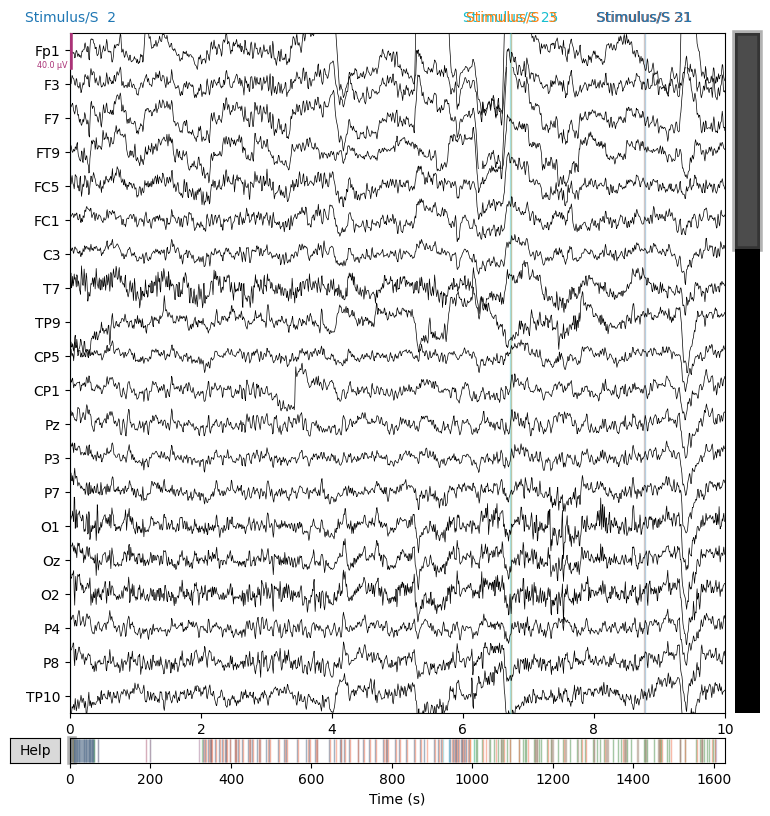

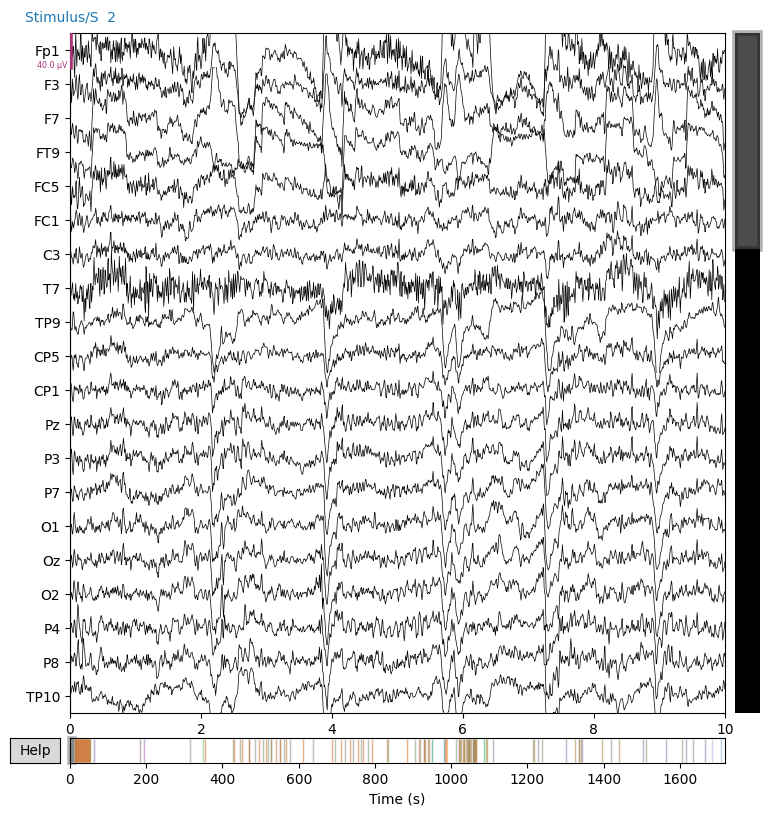

In [250]:
import os

output_dir = "tfr_results"
os.makedirs(output_dir, exist_ok=True)

for patient in patients:

    patient_id = get_patient_id(patient)  # or patient["name"]

    pre_tic_epochs, random_epochs = full_pipeline_extract_pre_tic_epochs(
        patient,
        phase="spontaneous_phase",
        nb_random_epochs=50
    )

    # --- PRE-TIC ---
    tfr_pre, freqs_pre, times_pre = tfr_per_ROI(
        patient,
        pre_tic_epochs,
        epoch_type="pre_tic"
    )

    fig_pre = plot_trf_roi(
        tfr_pre,
        freqs_pre,
        times_pre,
    )

    fig_pre.savefig(
        os.path.join(output_dir, f"patient_{patient_id}_pre_tic_TFR.png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.close(fig_pre)

    # --- RANDOM ---
    tfr_rand, freqs_rand, times_rand = tfr_per_ROI(
        patient,
        random_epochs,
        epoch_type="random"
    )

    fig_rand = plot_trf_roi(
        tfr_rand,
        freqs_rand,
        times_rand,
    )

    fig_rand.savefig(
        os.path.join(output_dir, f"patient_{patient_id}_random_TFR.png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.close(fig_rand)


# Functions for Imitated phase extraction and Suppressed 

In [350]:
def analyse_merged_ttl_tics_imitated(merged_ttl_tics,
                                    phase_start_key='start_spont',
                                    phase_end_key='end_spont'):

    t_start = next((list(d.values())[0] for d in merged_ttl_tics
                    if list(d.keys())[0] == phase_start_key), None)
    t_end   = next((list(d.values())[0] for d in merged_ttl_tics
                    if list(d.keys())[0] == phase_end_key), None)

    phase_events = [d for d in merged_ttl_tics
                    if t_start <= list(d.values())[0] <= t_end]

    results_list = []
    i = 0

    while i < len(phase_events):

        key, value = next(iter(phase_events[i].items()))

        # Real tic 
        if key == 'T':

            found_back = None
            for j in range(i-1, -1, -1):
                k, v = next(iter(phase_events[j].items()))
                if k.startswith('start_'):
                    found_back = ('start_i', v)
                    break
                elif k.startswith('end_'):
                    found_back = ('end_i', v)
                    break

            # Case 1: T after start_i 
            if found_back is not None and found_back[0] == 'start_i':
                results_list.append({
                    "type": "start_then_T",
                    "start_time": found_back[1],
                })
                print(f"start_tic at {found_back[1]} then T pressed at {value}")

            # Case 2: T after end_i
            elif found_back is not None and found_back[0] == 'end_i':

                found_forward = None
                for j_forward in range(i+1, len(phase_events)):
                    k_fwd, v_fwd = next(iter(phase_events[j_forward].items()))
                    if k_fwd.startswith('start_'):
                        found_forward = ('start_i', v_fwd)
                        break

                if found_forward is not None:
                    results_list.append({
                        "type": "T_then_start",
                        "T_time": value,
                    })
                    print(f"T pressed at {value} then tic starts at {found_forward[1]}")
                else:
                    results_list.append({
                        "type": "end_then_T",
                        "start_time": found_back[1],
                    })
                    print(f"T pressed at {value} after end of tic at {found_back[1]}")

        # Imitated tic 
        if key == 'D':

            found_back = None
            for j in range(i-1, -1, -1):
                k, v = next(iter(phase_events[j].items()))
                if k.startswith('start_'):
                    found_back = ('start_i', v)
                    break
                elif k.startswith('end_'):
                    found_back = ('end_i', v)
                    break

            # Case 1: D after start_i
            if found_back is not None and found_back[0] == 'start_i':
                results_list.append({
                    "type": "start_then_D",
                    "start_time": found_back[1],
                })
                print(f"start_tic at {found_back[1]} then D pressed at {value}")

            # Case 2: D after end_i
            else:
                found_forward = None
                for j_forward in range(i+1, len(phase_events)):
                    k_fwd, v_fwd = next(iter(phase_events[j_forward].items()))
                    if k_fwd.startswith('start_'):
                        found_forward = ('start_i', v_fwd)
                        break
                    elif k_fwd == 'F':
                        found_forward = ('F', v_fwd)
                        break

                if found_forward is not None and found_forward[0] == 'start_i':
                    results_list.append({
                        "type": "D_then_start",
                        "D_time": value,
                        })
                    print(f"D pressed at {value} then tic starts at {found_forward[1]}")
                else:
                    results_list.append({
                        "type": "D_then_F",
                        "D_time": value
                    })
                    print(f"D pressed at {value} without any visible tic then F pressed at {found_back[1]}")

        i += 1

    return results_list


In [ ]:
analyse_merged_ttl_tics_imitated(merged_ttl_tics,
                                    phase_start_key='start_spont',
                                    phase_end_key='end_spont')

In [351]:
def full_pipeline_extract_pre_tic_epochs(patient, phase,nb_random_epochs):
    # Run the full pipeline for the patient
    results = run_full_pipeline_for_patient(
        vhdr_path = patient["vhdr"],
        excel_path = patient["excel"],
        fps = patient["fps"],
        min_absence_frames = patient["min_absence_frames"],
        montage_name = patient["montage"],
        excel_phase_times = patient["excel_phase_times"],
        )
        
    phase_map = {
        "spontaneous_phase": ("start_spont", "end_spont"),
        "imitated_phase": ("start_imit", "end_imit"),
        "suppressed_phase": ("start_ret", "end_ret"),
        }
    filter_dict = {
        'D': 21, 
        'F': 22,
        'S': 23,
        'T': 24,
        'right': 25,
        'start_spont': 9,
        'end_spont': 10,
        'start_imit': 11,
        'end_imit': 12,
        'start_ret': 13,
        'end_ret': 14
        }
    phase_start_key, phase_end_key = phase_map[phase]

    #set the phase boundary 
    start_ttl_number = filter_dict[phase_start_key]
    end_ttl_number   = filter_dict[phase_end_key]

  
    ttl_info = results["ttl"]  

    start_time = next(ttl["time"] for ttl in ttl_info if int(ttl["ttl_name"].split()[-1]) == start_ttl_number)
    end_time   = next(ttl["time"] for ttl in ttl_info if int(ttl["ttl_name"].split()[-1]) == end_ttl_number)


    # Urges list 
    urges_list = {}
    analysis_list_patient = analyse_merged_ttl_tics_imitated(
        merged_ttl_tics=results["merged_ttl_tics"],
        phase_start_key = phase_start_key, 
        phase_end_key = phase_end_key,
        )
    urges_list[f"list_urges_{results['subject']}"] = analysis_list_patient

    # Shift urges to EEG time
    urges_list = urges_list[f"list_urges_{results['subject']}"]
    stim2_time = results["stim2_time_original"]

    urges_times_EEG_patient = shift_urges_times(
        urges_list=urges_list,
        stim2_time=stim2_time,
        )

    # Extract pre-tic epochs
    pre_tic_epochs = extract_pre_tic_epochs(
        raw_cropped =results["raw_cropped"],
        urge_times =urges_times_EEG_patient,
        pre_seconds=2.0, post_seconds=0.5
        )

    # Extract random epochs in the same phase
    random_epochs = extract_random_epochs_in_phase(
        raw_cropped=results["raw_cropped"],
        start_time=start_time,
        end_time=end_time,
        n_epochs=nb_random_epochs,
        epoch_duration=2.5,
        event_id=999,
        seed=42
        )
    
    return pre_tic_epochs, random_epochs


===== START Patient /Users/Tysia/Desktop/movidoc/tictrack_eeg_analysis/PATIENT FILES/EEG PATIENT FILES/MOVIDOCTicTrack_BB28-bis.vhdr =====

--- Traitement du fichier : _BB28-bis ---

Extracting parameters from /Users/Tysia/Desktop/movidoc/tictrack_eeg_analysis/PATIENT FILES/EEG PATIENT FILES/MOVIDOCTicTrack_BB28-bis.vhdr...
Setting channel info structure...
Reading 0 ... 841719  =      0.000 ...  1683.438 secs...


/Users/Tysia/Desktop/movidoc/tictrack_eeg_analysis/_02_Movidoc_tictrack_prepro_TTL_extraction_patients.py:62: RuntimeWarning: Online software filter detected. Using software filter settings and ignoring hardware values
  raw = mne.io.read_raw_brainvision(FilePath, preload=True)


['Fp1', 'F3', 'F7', 'FT9', 'FC5', 'FC1', 'C3', 'T7', 'TP9', 'CP5', 'CP1', 'Pz', 'P3', 'P7', 'O1', 'Oz', 'O2', 'P4', 'P8', 'TP10', 'CP6', 'CP2', 'Cz', 'C4', 'T8', 'FT10', 'FC6', 'FC2', 'F4', 'F8', 'Fp2']
None
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1651 samples (3.302 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.5s


Filtering raw data in 1 contiguous segment


[Parallel(n_jobs=1)]: Done  31 out of  31 | elapsed:    0.8s finished


Removed notch frequencies (Hz):
     50.00 : 10385 windows
Applying REST reference...
Fitted sphere radius:         96.0 mm
Origin head coordinates:      -0.9 13.5 42.7 mm
Origin device coordinates:    -0.9 13.5 42.7 mm

Equiv. model fitting -> RV = 0.00406411 %%
mu1 = 0.943578    lambda1 = 0.140053
mu2 = 0.664225    lambda2 = 0.686726
mu3 = 0.0340156    lambda3 = -0.01641
Set up EEG sphere model with scalp radius    96.0 mm

EEG channel type selected for re-referencing
Applying REST reference.
Applying a custom ('EEG',) reference.
    31 out of 31 channels remain after picking
Before crop: [ 0.     4.482  4.492 19.53  19.538]
Cropping EEG at stimulus 'Stimulus/S  2' = 19.538 s
DEBUG after set_annotations: [19.538 29.424 29.432 31.616 31.632]
Used Annotations descriptions: [np.str_('Stimulus/S  2'), np.str_('Stimulus/S  3'), np.str_('Stimulus/S  4'), np.str_('Stimulus/S  5'), np.str_('Stimulus/S  6'), np.str_('Stimulus/S  7'), np.str_('Stimulus/S  8'), np.str_('Stimulus/S  9'), np.str_

RuntimeError: Event time samples were not unique. Consider setting the `event_repeated` parameter."

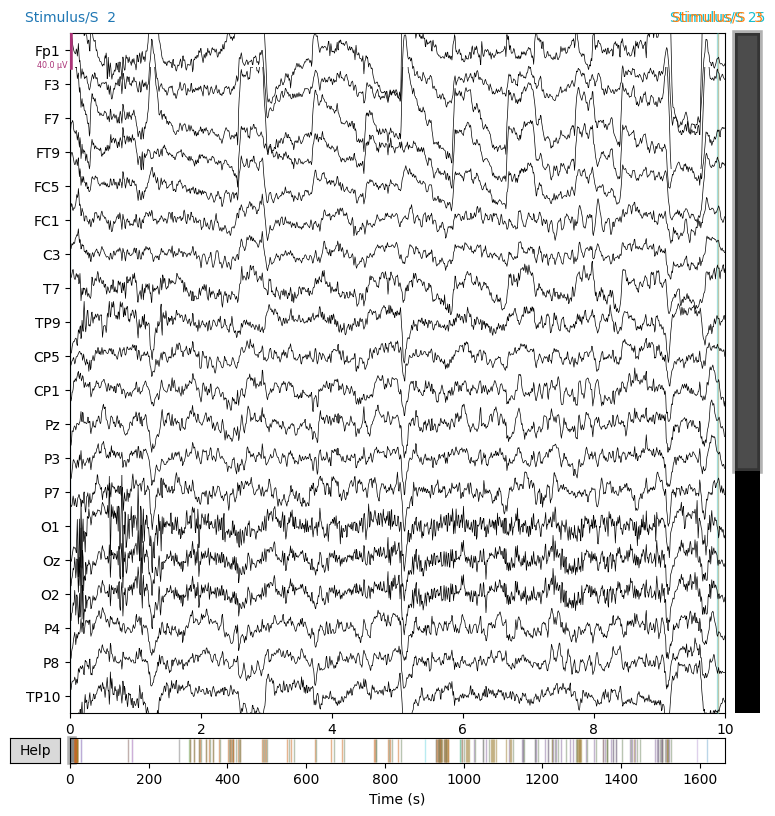

In [352]:
pre_tic_epochs_im, random_epochs_im = full_pipeline_extract_pre_tic_epochs(patients[1], phase="imitated_phase", nb_random_epochs=50)